In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "512741424"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"])
df

,Model,Compression,BLEU
0,pythia-70M,Original,0.41996
1,pythia-70M,8-bit,0.41390
2,pythia-70M,4-bit,0.39210
3,pythia-160M,Original,0.42493
4,pythia-160M,8-bit,0.42310
5,pythia-160M,4-bit,0.40604
6,pythia-410M,Original,0.43509
7,pythia-410M,8-bit,0.43612
8,pythia-410M,4-bit,0.42411
9,pythia-1B,Original,0.44180


# RQ-4: Generalizibility check

## RQ-1: precision vs task performance

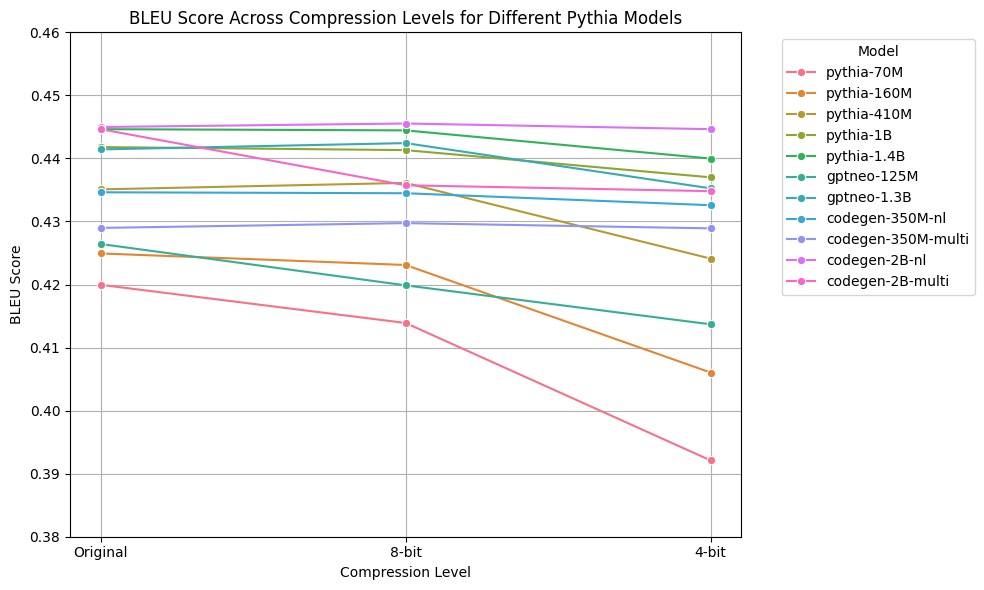

In [7]:
compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o")

plt.title("BLEU Score Across Compression Levels for Different Pythia Models")
plt.ylabel("BLEU Score")
plt.xlabel("Compression Level")
plt.ylim(0.38, 0.46)
plt.grid(True)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("./output/RQ-4.1.1.png", dpi=300, bbox_inches="tight")
plt.show()

## RQ-2: precision vs MIA

In [ ]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1.png"):
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Compression", y=score_col, hue="Model", marker="o")
    plt.title(f"{miaName}({score_col}) Score Across Compression Levels for Different Pythia Models")
    plt.ylabel(f"{score_col} Score")
    plt.xlabel("Compression Level")
    plt.grid(True)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}", dpi=300, bbox_inches="tight")
    plt.show()

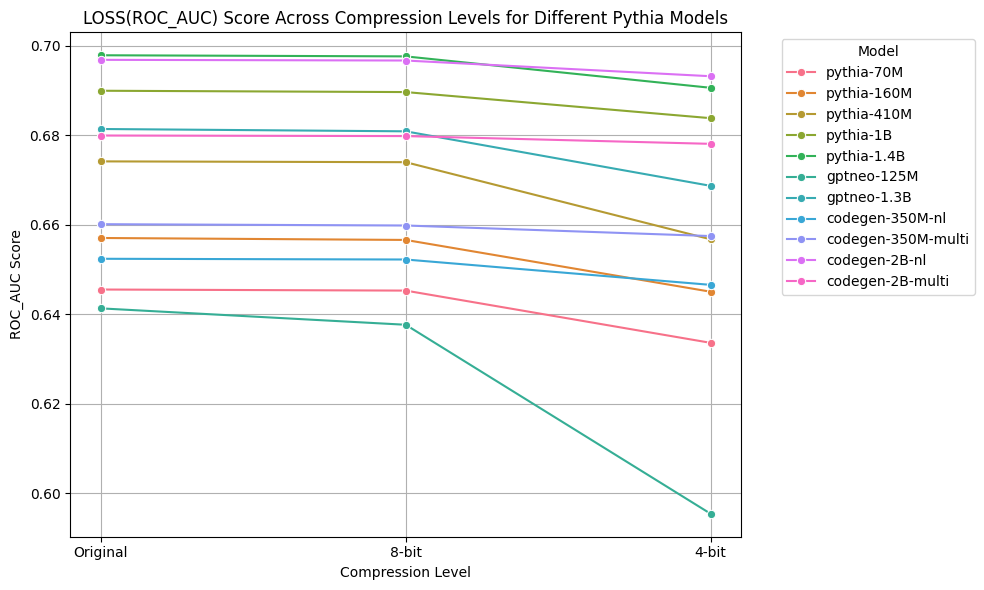

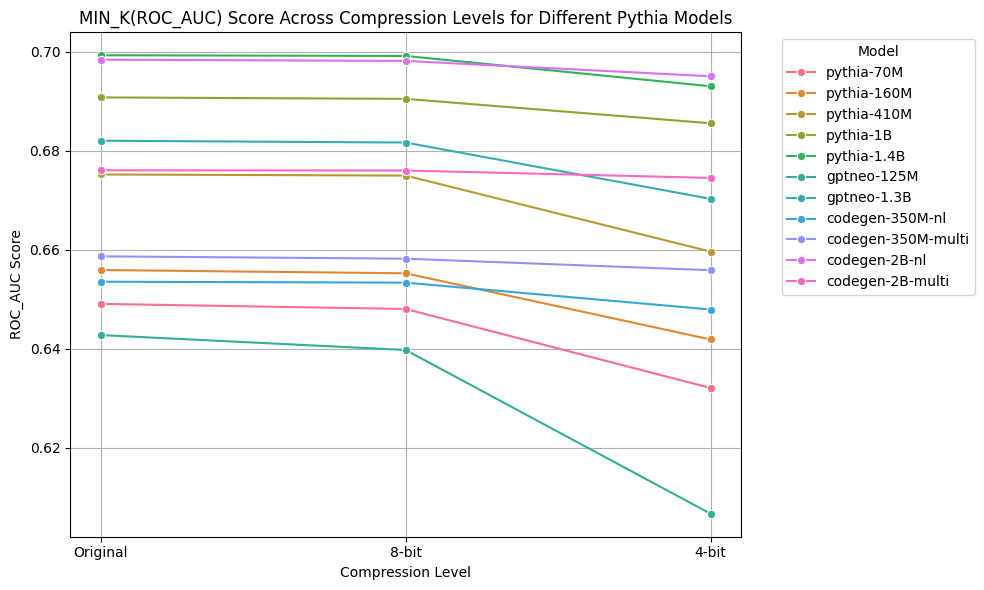

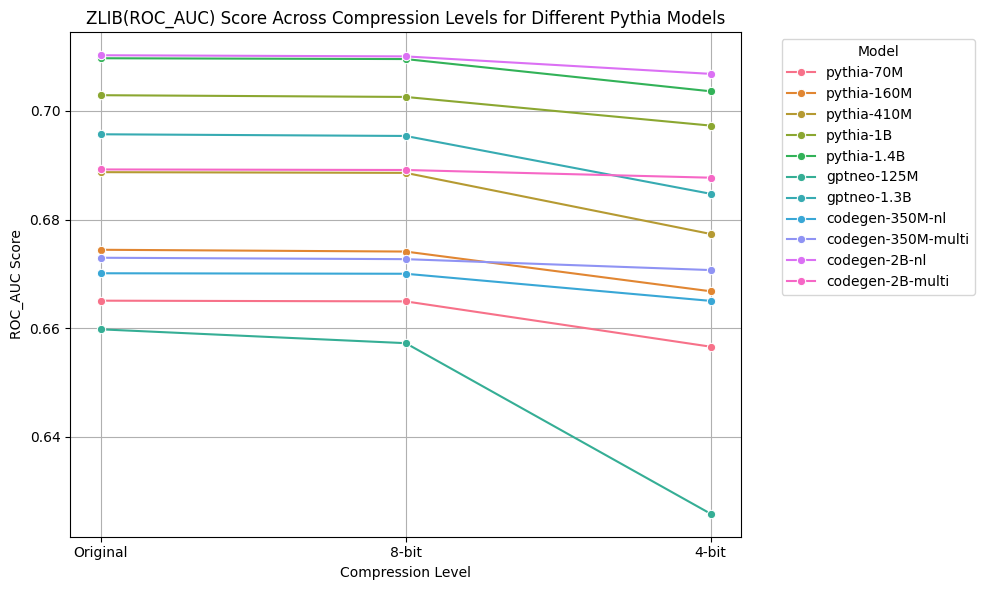

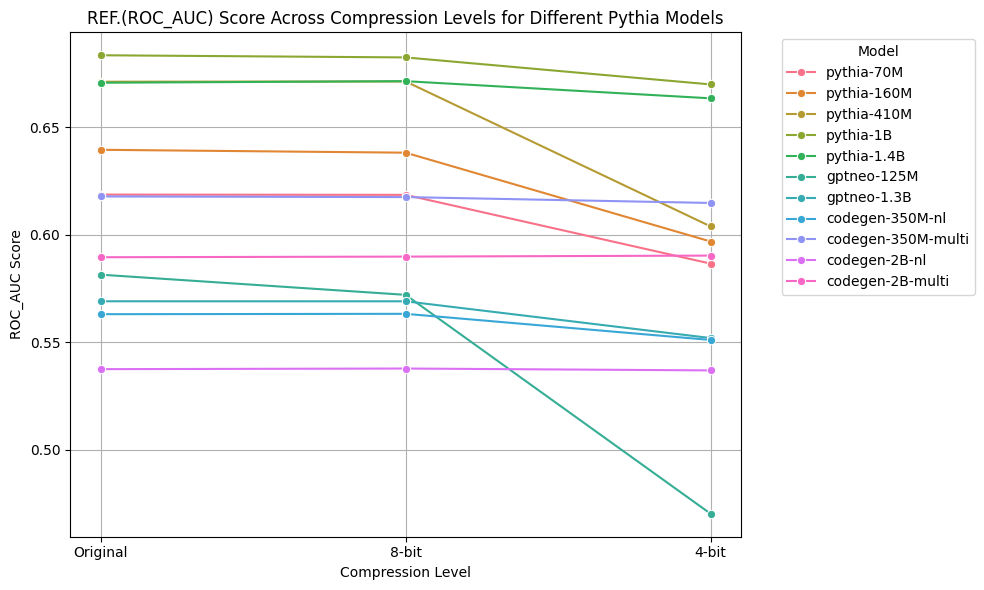

In [8]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"])
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"])
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-4.2.2.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-4.2.3.png")
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"])

df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-4.2.4.png")